In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
dataset = pd.read_csv(r"D:\python1\Week-9.1-Machine-Learning-Data-Science-Capstone-SLA-Prediction-Project\2.Data preprocessing\preprocessed_data.csv")

In [6]:
dataset

,Incident_ID,Incident_Type,Priority,Assigned_Department,Location,Status,Resolution_Type,Resolution_Time_Hours,Hour,Day,Month,SLA_Limit,SLA_Breached
0,INC100000,Network Outage,Low,Security Team,Data Center B,Resolved,Reboot,18.0,4,6,3,24,0
1,INC100001,Database Failure,Low,Database Admin,Remote Site 1,Resolved,Reboot,35.0,20,3,1,24,0
2,INC100002,Server Crash,Medium,Database Admin,Remote Site 2,Closed,Patch Applied,72.0,1,2,1,12,1
3,INC100003,Database Failure,Critical,Network Team,Remote Site 1,Resolved,Reboot,36.0,3,5,7,4,1
4,INC100004,Server Crash,Critical,Security Team,Head Office,Resolved,Configuration Fix,28.0,1,4,2,4,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,INC101195,Application Bug,Critical,Security Team,Remote Site 2,Resolved,Hardware Replacement,47.0,13,4,10,4,1
1196,INC101196,Security Breach,Low,Network Team,Data Center B,Resolved,Reboot,25.0,17,4,1,24,1
1197,INC101197,Network Outage,Medium,IT Support,Data Center B,Resolved,Patch Applied,19.0,5,3,6,12,1
1198,INC101198,Application Bug,Medium,IT Support,Head Office,Closed,Patch Applied,60.0,17,3,9,12,1


In [7]:
dataset.dtypes

Incident_ID               object
Incident_Type             object
Priority                  object
Assigned_Department       object
Location                  object
Status                    object
Resolution_Type           object
Resolution_Time_Hours    float64
Hour                       int64
Day                        int64
Month                      int64
SLA_Limit                  int64
SLA_Breached               int64
dtype: object

In [8]:
num_cols=dataset.select_dtypes(include=["int64","float64"]).columns 

In [9]:
num_cols

Index(['Resolution_Time_Hours', 'Hour', 'Day', 'Month', 'SLA_Limit',
       'SLA_Breached'],
      dtype='object')

In [10]:
dataset[num_cols]

,Resolution_Time_Hours,Hour,Day,Month,SLA_Limit,SLA_Breached
0,18.0,4,6,3,24,0
1,35.0,20,3,1,24,0
2,72.0,1,2,1,12,1
3,36.0,3,5,7,4,1
4,28.0,1,4,2,4,1
...,...,...,...,...,...,...
1195,47.0,13,4,10,4,1
1196,25.0,17,4,1,24,1
1197,19.0,5,3,6,12,1
1198,60.0,17,3,9,12,1


# Correlation

In [11]:
corr=dataset[num_cols].corr()

In [12]:
corr

,Resolution_Time_Hours,Hour,Day,Month,SLA_Limit,SLA_Breached
Resolution_Time_Hours,1.000000,0.020600,-0.010790,0.021706,0.025152,0.553474
Hour,0.020600,1.000000,0.028819,0.030873,0.015783,0.018823
Day,-0.010790,0.028819,1.000000,-0.004596,-0.006997,-0.004948
Month,0.021706,0.030873,-0.004596,1.000000,-0.004550,0.020923
SLA_Limit,0.025152,0.015783,-0.006997,-0.004550,1.000000,-0.297400
SLA_Breached,0.553474,0.018823,-0.004948,0.020923,-0.297400,1.000000


# Correlation Heatmap

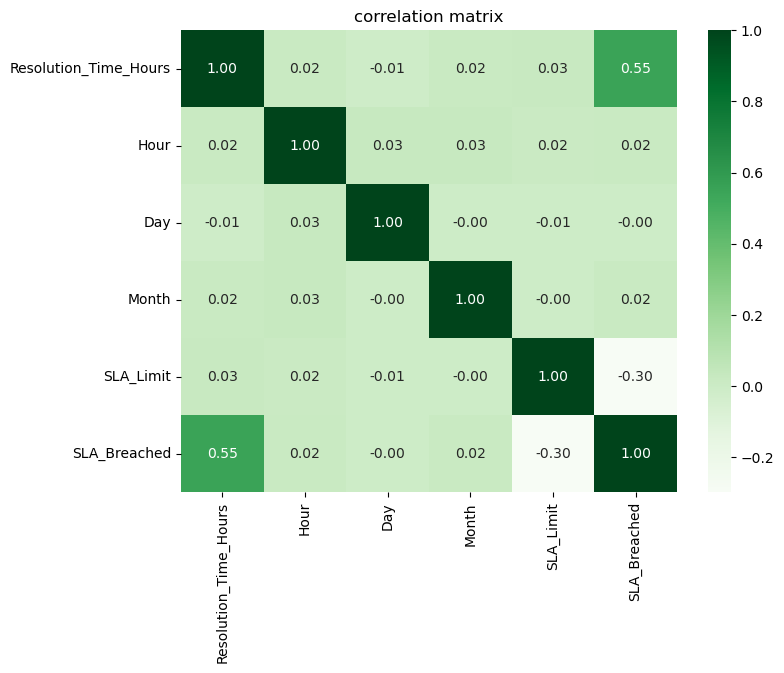

In [16]:
plt.figure(figsize=(8,6))
sns.heatmap(corr,annot=True,cmap="Greens",fmt=".2f")
plt.title("correlation matrix")
plt.show()

#  Pair Plot

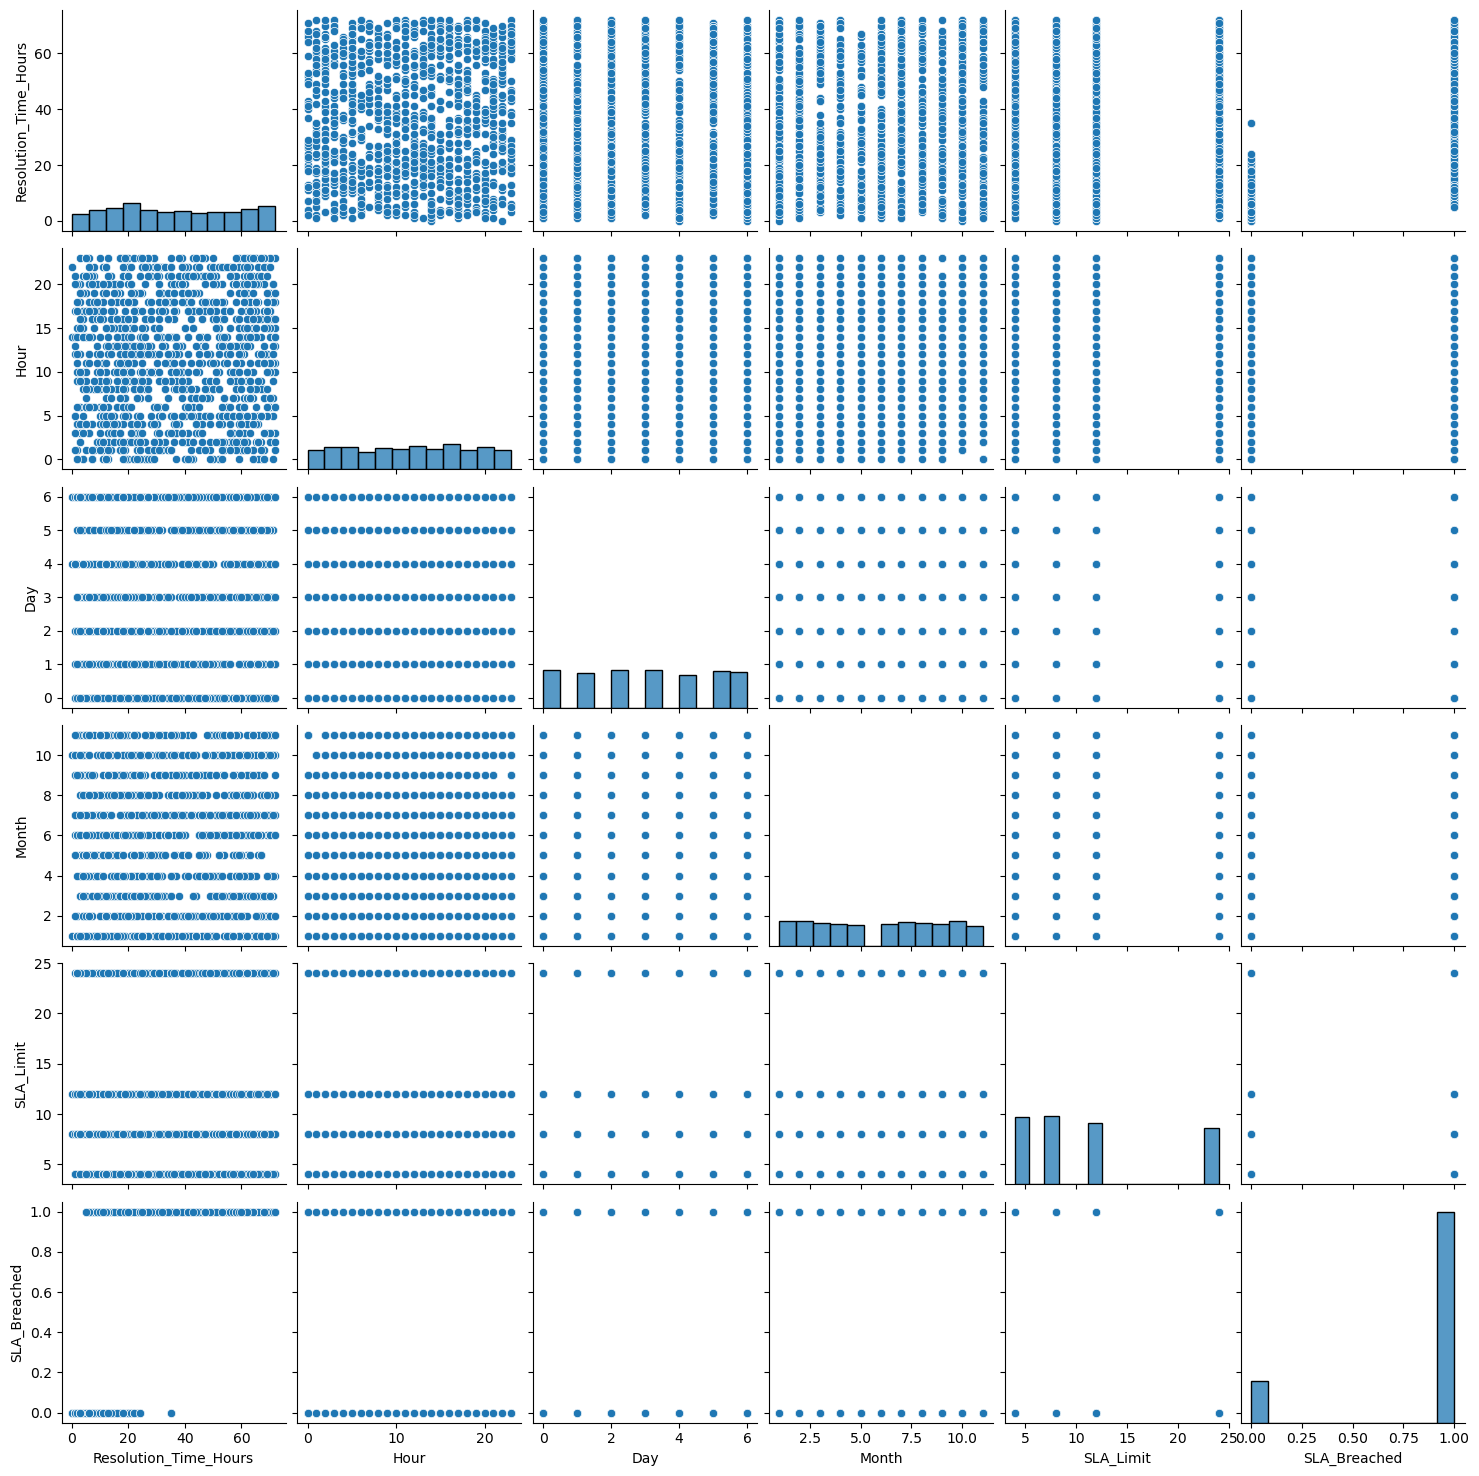

In [17]:
sns.pairplot(dataset)
plt.show()

# Scatter Plot

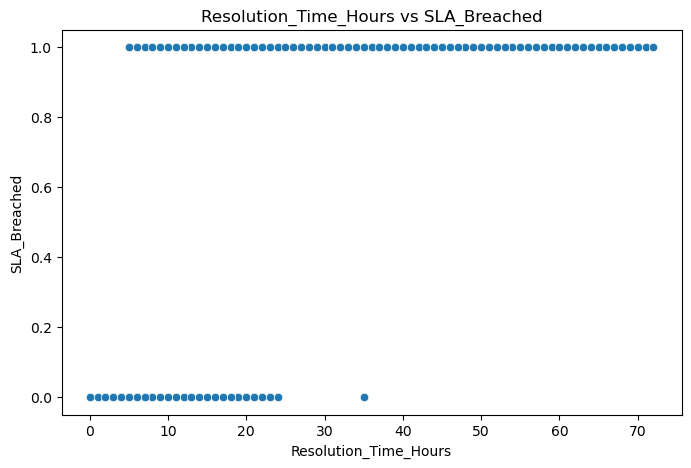

In [22]:
x_col="Resolution_Time_Hours"
y_col="SLA_Breached"
plt.figure(figsize=(8,5))
sns.scatterplot(data=dataset,x=x_col,y=y_col)
plt.title(f"{x_col} vs {y_col}")
plt.show()

# Box Plot

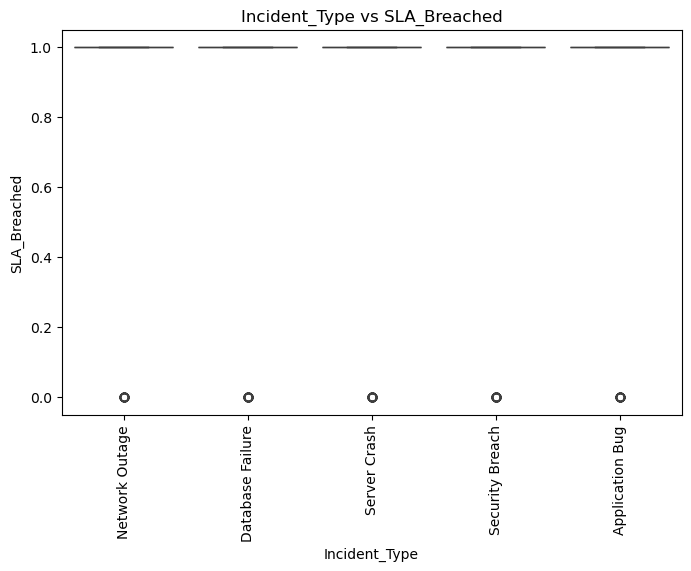

In [26]:
cat_cols="Incident_Type"
num_cols="SLA_Breached"
plt.figure(figsize=(8,5))
sns.boxplot(data=dataset,x=cat_cols,y=num_cols)
plt.xticks(rotation=90)
plt.title(f"{cat_cols} vs {num_cols}")
plt.show()

# Variance Inflation Factor

In [27]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
def calc_vif(x):
    vif=pd.DataFrame()
    vif["variables"]=x.columns
    vif["VIF"]=[variance_inflation_factor(x.values,i) for i in range(x.shape[1])]
    return vif

In [28]:
num_cols = ['Resolution_Time_Hours', 'Hour', 'Day', 'Month', 'SLA_Limit','SLA_Breached']
calc_vif(dataset[num_cols])

,variables,VIF
0,Resolution_Time_Hours,5.989247
1,Hour,3.407844
2,Day,2.849886
3,Month,3.737288
4,SLA_Limit,2.972069
5,SLA_Breached,7.512574


# T-Test 

In [29]:
from scipy.stats import ttest_ind
Network_Team_SLA_Breached=dataset[dataset["Assigned_Department"]=="Network Team"]["SLA_Breached"]
Security_Team_SLA_Breached=dataset[dataset["Assigned_Department"]=="Security Team"]["SLA_Breached"]
t_stat,p_value=ttest_ind(Network_Team_SLA_Breached,Security_Team_SLA_Breached,equal_var=False)

In [30]:
t_stat,p_value

(np.float64(-1.2077163324001525), np.float64(0.22779388618422763))

# ANOVA (Analysis of Variance)

In [33]:
from scipy.stats import f_oneway
Network_Team_SLA_Breached=dataset[dataset["Assigned_Department"]=="Network Team"]["SLA_Breached"]
Security_Team_SLA_Breached=dataset[dataset["Assigned_Department"]=="Security Team"]["SLA_Breached"]
Database_Admin_SLA_Breached=dataset[dataset["Assigned_Department"]=="Database Admin"]["SLA_Breached"]
f_stat,p_value=f_oneway(Network_Team_SLA_Breached,Security_Team_SLA_Breached,Database_Admin_SLA_Breached)

In [34]:
f_stat,p_value

(np.float64(0.7297541881000221), np.float64(0.482405682235144))